In [1]:
!nvidia-smi
!nvcc --version

Thu Apr 30 18:38:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/DhritiJindal13/UCS645-Project-Stock-Analysis
%cd UCS645-Project-Stock-Analysis
!ls -la

Cloning into 'UCS645-Project-Stock-Analysis'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 61 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 6.20 MiB | 12.75 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/UCS645-Project-Stock-Analysis
total 6612
drwxr-xr-x 5 root root    4096 Apr 30 18:38  .
drwxr-xr-x 1 root root    4096 Apr 30 18:38  ..
-rw-r--r-- 1 root root  878800 Apr 30 18:38  app
-rw-r--r-- 1 root root    1270 Apr 30 18:38  backtest.csv
-rw-r--r-- 1 root root    3993 Apr 30 18:38  backtester.hpp
-rw-r--r-- 1 root root     491 Apr 30 18:38  build.bat
drwxr-xr-x 2 root root    4096 Apr 30 18:38 'csv files'
-rw-r--r-- 1 root root 5773805 Apr 30 18:38  CUDA-Accelerated-Stock-Trading-Model-with-Technical-Indicator-Analysis.pptx
-rw-r--r-- 1 root root    8624 Apr 30 18:38  decision_logic.hpp
-rw-r--r-- 1 root root     876 Apr 30

In [3]:
import os, shutil

print("Files in 'csv files/' folder:")
!ls -la 'csv files/'

for f in os.listdir('csv files'):
    if f.endswith('.csv'):
        shutil.copy(f'csv files/{f}', f'./{f}')
        print(f'Copied: {f}')

print('\nCSVs in working directory:')
!ls *.csv

Files in 'csv files/' folder:
total 892
drwxr-xr-x 2 root root   4096 Apr 30 18:38 .
drwxr-xr-x 5 root root   4096 Apr 30 18:38 ..
-rw-r--r-- 1 root root 138835 Apr 30 18:38 backtest.csv
-rw-r--r-- 1 root root 506258 Apr 30 18:38 indicators.csv
-rw-r--r-- 1 root root      1 Apr 30 18:38 Readme.md
-rw-r--r-- 1 root root 252544 Apr 30 18:38 TSLA_data.csv
Copied: TSLA_data.csv
Copied: indicators.csv
Copied: backtest.csv

CSVs in working directory:
backtest.csv  indicators.csv  signals.csv  TSLA_data.csv


In [4]:
!apt-get install -y libcurl4-openssl-dev > /dev/null 2>&1

!mkdir -p include/nlohmann
!wget -q https://raw.githubusercontent.com/nlohmann/json/develop/single_include/nlohmann/json.hpp -O include/nlohmann/json.hpp

print('libcurl installed')
print('nlohmann/json downloaded')

libcurl installed
nlohmann/json downloaded


In [5]:
!sed -i 's/TIME_SERIES_INTRADAY/TIME_SERIES_DAILY/g' fetcher.hpp
!sed -i 's/\&interval=" + interval + "//g' fetcher.hpp
!sed -i 's/std::string time_series_key = "Time Series (" + interval + ")"/std::string time_series_key = "Time Series (Daily)"/g' fetcher.hpp

print('fetcher.hpp patched successfully')

!grep -n 'TIME_SERIES\|time_series_key\|interval' fetcher.hpp | head -10

fetcher.hpp patched successfully
37:inline bool fetch_stock_data(const std::string &symbol, const std::string &interval,
41:    std::string url = "https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=" +
77:        std::string time_series_key = "Time Series (Daily)";
78:        if (!jsonData.contains(time_series_key))
85:        auto timeSeries = jsonData[time_series_key];
180:                           const std::string &interval,   // ignored for daily
188:    if (!fetch_stock_data(symbol, interval, api_key, filename))


In [6]:
!nvcc main.cpp -o stock_analysis -std=c++17 -lcurl -I./include 2>&1

import os
if os.path.exists('./stock_analysis'):
    print('Compilation successful. Binary created.')
else:
    print('Compilation failed. Check errors above.')

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compilation successful. Binary created.


In [7]:
!./stock_analysis 2>&1

Starting stock analysis program for TSLA
GPU acceleration: disabled
✅ Data saved to TSLA_data.csv (Daily data - last 100 days)
Successfully fetched 100 data points.
Date range: 2026-04-29 to 2025-12-04
Computing SMA with period 20 on 100 prices
SMA calculation complete. Output size: 81
SMA Calculation Time: 0.035414 ms
Computing EMA with period 20 on 100 prices
EMA calculation complete. Output size: 81
EMA Calculation Time: 0.02001 ms
Computing RSI with period 14 on 100 prices
RSI calculation complete. Output size: 86
RSI Calculation Time: 0.027826 ms
Computing Bollinger Bands with period=20, stdDev=2 on 100 prices
Bollinger Bands calculation complete. Size: 81
Bollinger Bands Calculation Time: 0.118077 ms
Computing MACD with fast=12, slow=26, signal=9 on 100 prices
Computing EMA with period 12 on 100 prices
EMA calculation complete. Output size: 89
Computing EMA with period 26 on 100 prices
EMA calculation complete. Output size: 75
MACD calculation complete. MACD size: 75, Signal size

In [8]:
import os
for f in ['TSLA_data.csv', 'indicators.csv', 'backtest.csv']:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    status = 'Found' if exists else 'NOT FOUND'
    print(f"{f}: {status}{' (' + str(size) + ' bytes)' if exists else ''}")

TSLA_data.csv: Found (5637 bytes)
indicators.csv: Found (8216 bytes)
backtest.csv: Found (1273 bytes)


In [9]:
import pandas as pd

print('=== TSLA Stock Data (last 5 rows) ===')
try:
    df = pd.read_csv('TSLA_data.csv')
    display(df.tail())
except Exception as e:
    print(f'Error: {e}')

=== TSLA Stock Data (last 5 rows) ===


,Date,Open,High,Low,Close,Volume
95,2026-04-23,375.280,386.00,368.39,373.72,93969510
96,2026-04-24,373.500,382.76,370.73,376.30,62893307
97,2026-04-27,372.090,380.78,364.02,378.67,66735816
98,2026-04-28,374.675,382.29,372.54,376.02,50864357
99,2026-04-29,375.400,376.40,370.04,372.80,45384836


In [10]:
print('=== Technical Indicators (last 5 rows) ===')
try:
    df = pd.read_csv('indicators.csv')
    display(df.tail())
    print(f'\nColumns: {list(df.columns)}')
except Exception as e:
    print(f'Error: {e}')

=== Technical Indicators (last 5 rows) ===


,Date,Price,SMA,EMA,RSI,BB_Mid,BB_Upper,BB_Lower,MACD,Signal,Histogram,Stoch_K,Stoch_D,ATR
69,2026-04-23,373.72,383.860,381.830,36.4339,383.860,412.989,354.730,-0.533844,-6.39634,5.86250,50.46600,37.3322,13.2436
70,2026-04-24,376.30,381.664,379.067,31.9475,381.664,413.109,350.219,0.293976,-5.05828,5.35225,32.53300,39.7875,13.4291
71,2026-04-27,378.67,379.063,375.980,40.2273,379.063,412.960,345.166,-0.160889,-4.07880,3.91791,4.16994,29.0563,13.7106
72,2026-04-28,376.02,376.263,372.863,41.5231,376.263,412.219,340.308,-0.309601,-3.32496,3.01536,6.74093,14.4813,13.5291
73,2026-04-29,372.80,373.154,370.268,43.2963,373.154,408.406,337.901,-0.233521,-2.70667,2.47315,31.56770,14.1595,13.5056



Columns: ['Date', 'Price', 'SMA', 'EMA', 'RSI', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'MACD', 'Signal', 'Histogram', 'Stoch_K', 'Stoch_D', 'ATR']


In [11]:
print(' Backtest Results (last 5 rows) ')
try:
    df = pd.read_csv('backtest.csv')
    display(df.tail())
    buys = len(df[df['action'] == 'BUY']) if 'action' in df.columns else 'N/A'
    sells = len(df[df['action'] == 'SELL']) if 'action' in df.columns else 'N/A'
    print(f'\nTotal BUY signals: {buys}')
    print(f'Total SELL signals: {sells}')
except Exception as e:
    print(f'Error: {e}')

=== Backtest Results (last 5 rows) ===


,date,portfolio_value,action,price
46,2026-02-11,10149.5,HOLD,0
47,2026-02-12,10149.5,HOLD,0
48,2026-02-13,10149.5,HOLD,0
49,2026-02-17,10149.5,HOLD,0
50,2026-02-18,10149.5,HOLD,0



Total BUY signals: 0
Total SELL signals: 0


In [12]:
!pip install matplotlib pandas numpy mplfinance -q
print('Python packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.9 MB/s eta 0:00:00
Python packages ready


In [13]:
%matplotlib inline
import matplotlib
matplotlib.use('Agg')

!python plotter.py 2>&1

print('\nGenerated chart files:')
!ls *.png 2>/dev/null || echo 'No PNG files found'

candlestick_bollinger.png saved
technical_indicators.png saved
portfolio_actions.png saved

Generated chart files:
candlestick_bollinger.png  portfolio_actions.png  technical_indicators.png



candlestick_bollinger.png


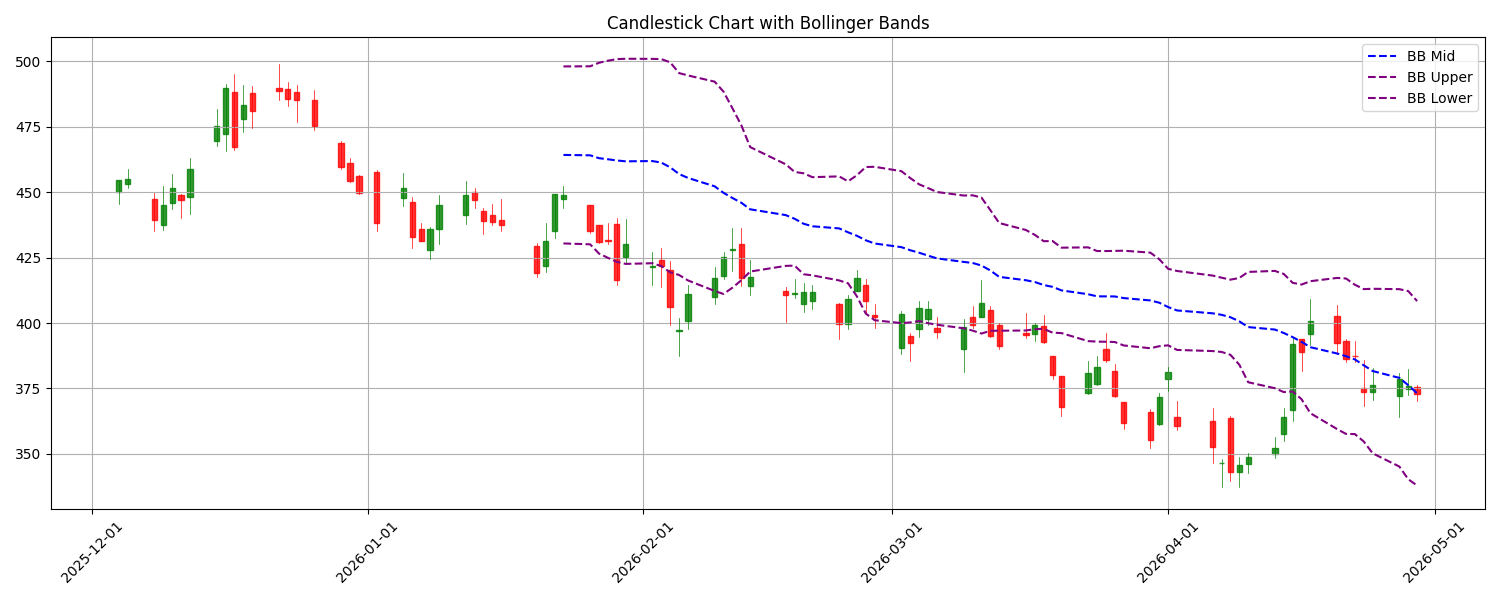


technical_indicators.png


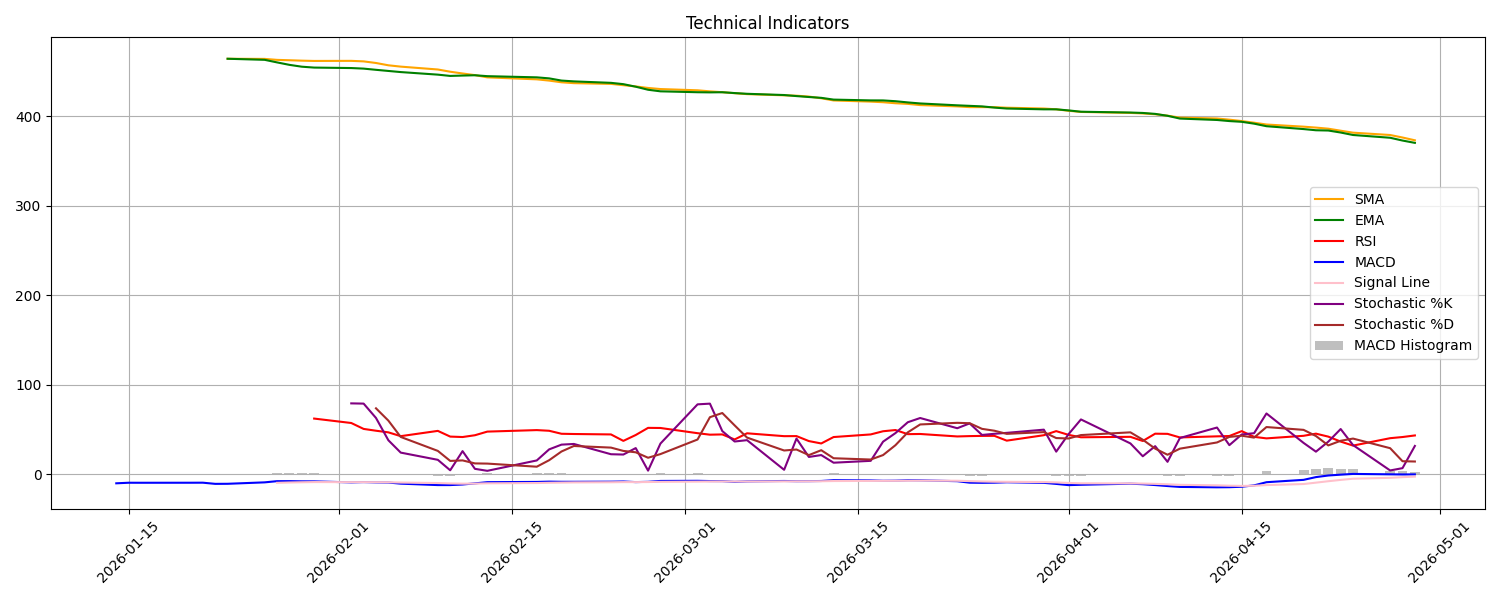


portfolio_actions.png


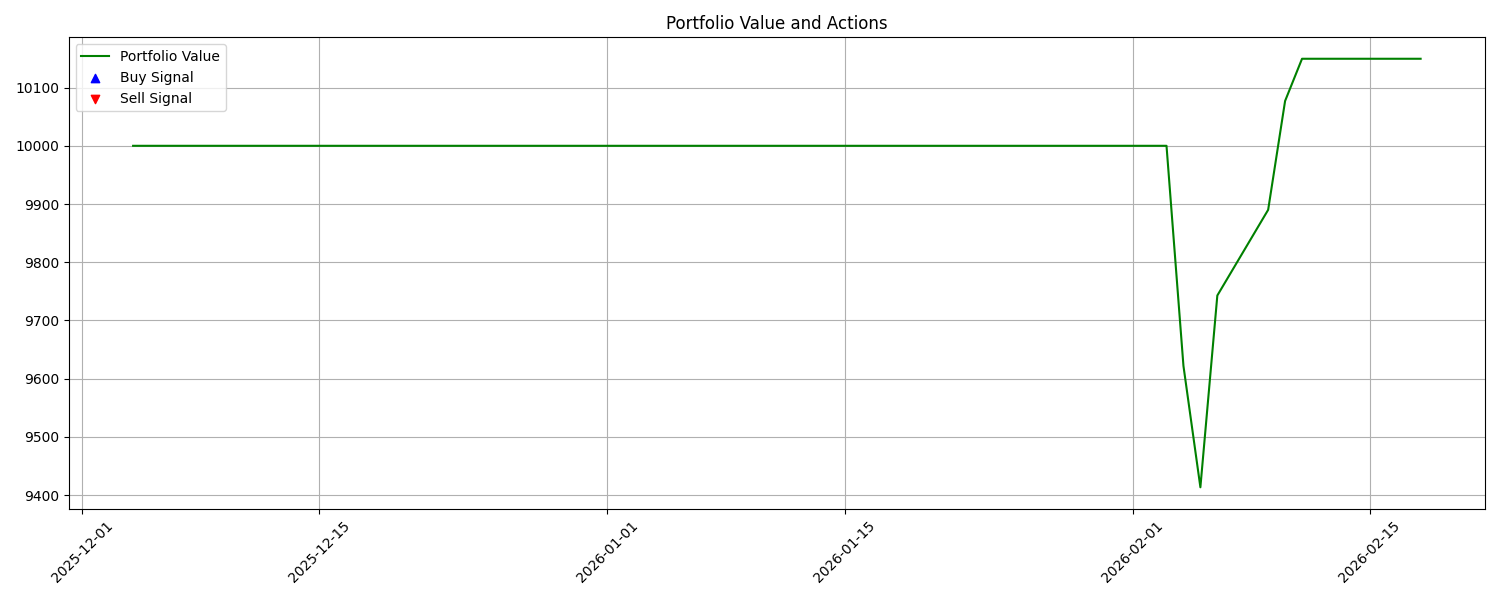

In [14]:
from IPython.display import Image, display
import os

charts = ['candlestick_bollinger.png', 'technical_indicators.png', 'portfolio_actions.png']
for chart in charts:
    if os.path.exists(chart):
        print(f'\n{chart}')
        display(Image(chart))
    else:
        print(f'{chart} not found')